# Система Росса: несколько ремонтников и разное число машин
Дополнительные задания §7.3.4 и параметрическая серия §7.4.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("RossRepair.jl"))
using .RossRepair
include(srcdir("experiment_support.jl"))

mean_interval (generic function with 1 method)

## План независимых повторов

In [2]:
machine_counts, repairer_counts = [5,10,20], [1,2,3]
spares, replications = 3, 200
failure_mean, repair_mean = 100.0, 1.0
replicates, comparisons = NamedTuple[], NamedTuple[]

(NamedTuple[], NamedTuple[])

## Моделирование и решение поглощающей марковской цепи
Для каждого сочетания — отдельные независимые seed. Все траектории выполняются
теми же процессами ConcurrentSim; отключается только сохранение длинного журнала.

In [3]:
for (index,(N,r)) in enumerate(Iterators.product(machine_counts,repairer_counts))
    rows = NamedTuple[]
    for replication in 1:replications
        seed = 710000+1000*index+replication
        result = simulate_repair(; N, S=spares, repairers=r, failure_mean, repair_mean,
            seed, record_events=false)
        push!(rows,merge((experiment=index,replication=replication,seed=seed),result.summary))
    end
    append!(replicates,rows)
    sample = DataFrame(rows)
    estimate = mean_interval(sample.crash_time)
    theory = analytic_repair(;N,S=spares,repairers=r,failure_mean,repair_mean)
    push!(comparisons,(experiment=index,N=N,S=spares,repairers=r,replications=replications,
        mean_time=estimate.mean,se=estimate.se,ci_low=estimate.ci_low,ci_high=estimate.ci_high,
        theory_time=theory.mean_time,relative_error=(estimate.mean/theory.mean_time-1),
        ci_contains_theory=estimate.ci_low<=theory.mean_time<=estimate.ci_high,
        utilization=sum(sample.area_busy)/(r*sum(sample.crash_time)),theory_utilization=theory.utilization,
        mean_queue=sum(sample.area_queue)/sum(sample.crash_time),theory_queue=theory.mean_queue))
    println("N=$N, repairers=$r, runs=$replications, mean=$(round(estimate.mean;digits=2)) h")
end
results, comparison = DataFrame(replicates),DataFrame(comparisons)
save_table("ross_param_replicates.csv",results)
save_table("ross_param_comparison.csv",comparison)
select(comparison,:N,:repairers,:mean_time,:se,:ci_low,:ci_high,:theory_time,:relative_error,:ci_contains_theory)

N=5, repairers=1, runs=200, mean=187130.07 h


N=10, repairers=1, runs=200, mean=12102.43 h


N=20, repairers=1, runs=200, mean=985.02 h


N=5, repairers=2, runs=200, mean=700789.78 h


N=10, repairers=2, runs=200, mean=52858.15 h


N=20, repairers=2, runs=200, mean=3331.38 h


N=5, repairers=3, runs=200, mean=1.00350275e6 h


N=10, repairers=3, runs=200, mean=67627.88 h


N=20, repairers=3, runs=200, mean=4749.87 h


Row,N,repairers,mean_time,se,ci_low,ci_high,theory_time,relative_error,ci_contains_theory
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Bool
1,5,1,1.8713e5,15743.5,1.56085e5,2.18175e5,177280.0,0.0555622,true
2,10,1,12102.4,875.146,10376.7,13828.2,12340.0,-0.0192517,true
3,20,1,985.023,72.8567,841.352,1128.69,970.0,0.0154873,true
4,5,2,7.0079e5,51294.0,5.9964e5,8.01939e5,690080.0,0.0155196,true
5,10,2,52858.2,3778.58,45407.0,60309.3,46540.0,0.135757,true
6,20,2,3331.38,236.121,2865.76,3797.0,3395.0,-0.0187386,true
7,5,3,1.0035e6,76581.9,8.52487e5,1.15452e6,1.02648e6,-0.0223845,true
8,10,3,67627.9,5166.64,57439.5,77816.3,68640.0,-0.0147454,true
9,20,3,4749.87,354.621,4050.57,5449.16,4920.0,-0.0345799,true


## Время до аварии: среднее, интервал и аналитика

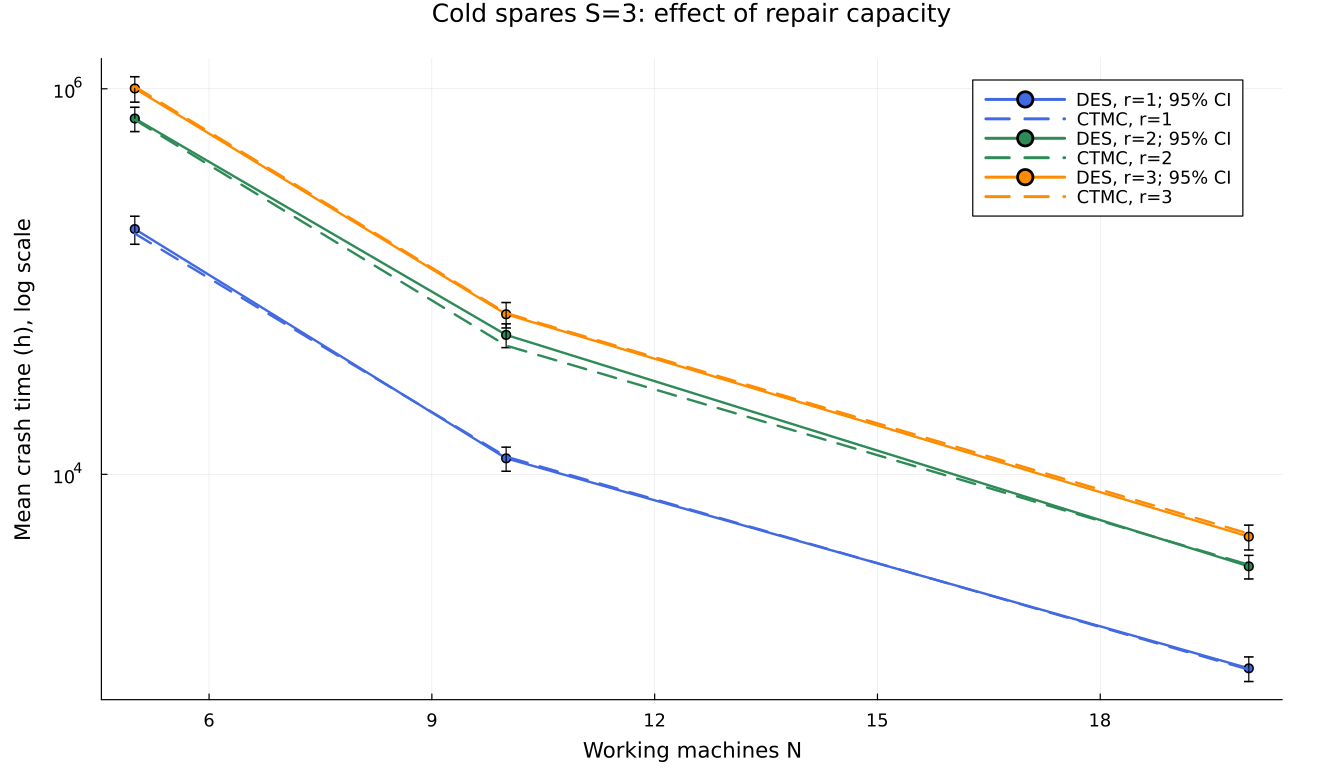

In [4]:
p_time=plot(;xlabel="Working machines N",ylabel="Mean crash time (h), log scale",
    yscale=:log10,title="Cold spares S=3: effect of repair capacity")
for (index,r) in enumerate(repairer_counts)
    rows=filter(:repairers=>==(r),comparison)
    color=[:royalblue,:seagreen,:darkorange][index]
    plot!(p_time,rows.N,rows.mean_time; yerror=(rows.mean_time-rows.ci_low,rows.ci_high-rows.mean_time),
        color,marker=:circle,label="DES, r=$r; 95% CI")
    plot!(p_time,rows.N,rows.theory_time;color,linestyle=:dash,label="CTMC, r=$r")
end
savefig(p_time,imagepath("09-plot.png"))
display(p_time)

## Интегральная загрузка и очередь ремонта

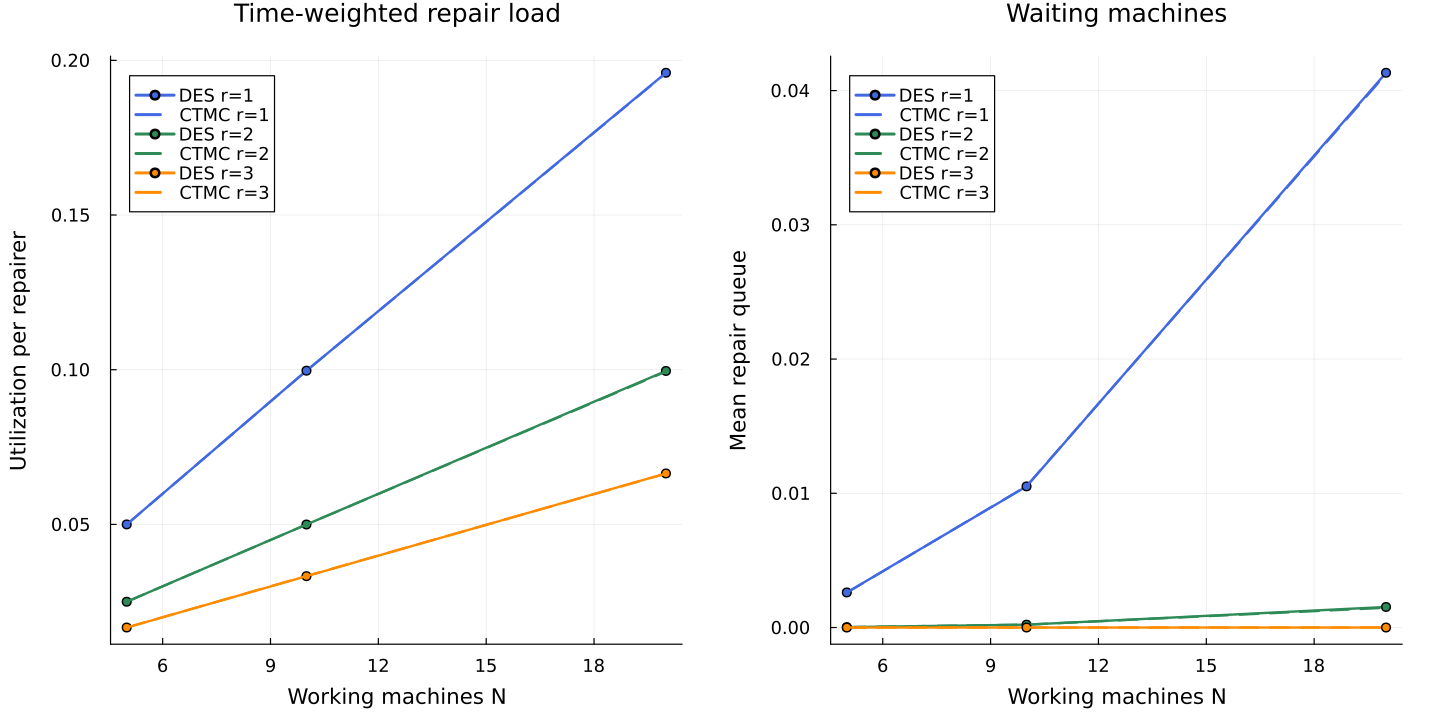

Row,N,repairers,utilization,theory_utilization,mean_queue,theory_queue
,Int64,Int64,Float64,Float64,Float64,Float64
1,5,1,0.0499954,0.0499774,0.00261325,0.00259477
2,10,1,0.0996871,0.0996759,0.0105142,0.0105348
3,20,1,0.195983,0.195876,0.0413261,0.0412371
4,5,2,0.025004,0.0249971,2.93903e-5,2.89821e-5
5,10,2,0.0499678,0.049957,0.000213268,0.000214869
6,20,2,0.0996,0.0994109,0.00153161,0.00147275
7,5,3,0.016674,0.0166654,0.0,0.0
8,10,3,0.033271,0.0333139,0.0,0.0
9,20,3,0.0664693,0.0663957,0.0,0.0


In [5]:
p_util=plot(;xlabel="Working machines N",ylabel="Utilization per repairer",title="Time-weighted repair load")
p_queue=plot(;xlabel="Working machines N",ylabel="Mean repair queue",title="Waiting machines")
for (index,r) in enumerate(repairer_counts)
    rows=filter(:repairers=>==(r),comparison)
    color=[:royalblue,:seagreen,:darkorange][index]
    plot!(p_util,rows.N,rows.utilization;color,marker=:circle,label="DES r=$r")
    plot!(p_util,rows.N,rows.theory_utilization;color,linestyle=:dash,label="CTMC r=$r")
    plot!(p_queue,rows.N,rows.mean_queue;color,marker=:circle,label="DES r=$r")
    plot!(p_queue,rows.N,rows.theory_queue;color,linestyle=:dash,label="CTMC r=$r")
end
p_monitor=plot(p_util,p_queue;layout=(1,2),size=(1200,600))
savefig(p_monitor,imagepath("10-plot.png"))
display(p_monitor)
select(comparison,:N,:repairers,:utilization,:theory_utilization,:mean_queue,:theory_queue)

## Проверка утверждения о числе резервных машин
Это аналитическое дополнение, не ещё одна имитационная серия.

In [6]:
reserve_check=DataFrame([(N=10,S=S,repairers=1,mean_time=analytic_repair(S=S).mean_time,
    recurrence=one_repair_mean(10,S,100.0,1.0)) for S in 0:5])
save_table("ross_reserve_analytic.csv",reserve_check)
reserve_check

Row,N,S,repairers,mean_time,recurrence
,Int64,Int64,Int64,Float64,Float64
1,10,0,1,10.0,10.0
2,10,1,1,120.0,120.0
3,10,2,1,1230.0,1230.0
4,10,3,1,12340.0,12340.0
5,10,4,1,123450.0,123450.0
6,10,5,1,1.23456e6,1.23456e6
